# LIBRERIAS

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import dask
import netCDF4
import xarray as xr
import rioxarray
import seaborn as sns
import math
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal

# LECTURA DE DATOS

In [16]:
data_dir = Path("D:/Doctorado/Courses/Hidroinformatica/Hidroinformatica26/Tarea1/Estaciones Aut - Precipitación")

data_files = list(data_dir.glob("*.data"))

print(f"Archivos encontrados: {len(data_files)}")

Archivos encontrados: 611


In [17]:
def read_climate_data(file_path, chunksize=300_000):
    chunks = []

    for chunk in pd.read_csv(
        file_path,
        sep="|",
        parse_dates=["Fecha"],
        dtype={"Valor": "float32"},
        chunksize=chunksize
    ):
        # Metadatos desde el nombre del archivo
        chunk["station_id"] = file_path.stem.split("@")[-1]
        chunk["variable"] = file_path.stem.split("@")[0]

        chunks.append(chunk)

    return pd.concat(chunks, ignore_index=True)

In [18]:
dfs = []

for file in data_files:
    df = read_climate_data(file)
    dfs.append(df)

climate_df = pd.concat(dfs, ignore_index=True)

In [19]:
print(climate_df.head())

                Fecha  Valor station_id   variable
0 2019-07-06 00:20:00    0.0   11017020  PT_AUT_10
1 2019-07-06 00:30:00    0.0   11017020  PT_AUT_10
2 2019-07-06 00:40:00    0.0   11017020  PT_AUT_10
3 2019-07-06 00:50:00    0.0   11017020  PT_AUT_10
4 2019-07-06 01:00:00    0.0   11017020  PT_AUT_10


# PUNTO 1 - 2

In [41]:
# df ya leído desde parquet
df = climate_df

df["Fecha"] = pd.to_datetime(df["Fecha"])
df = df.sort_values("Fecha")

df_5y = df[
    (df["Fecha"] >= "2015-01-01") &
    (df["Fecha"] < "2020-01-01")
].copy()

In [42]:
df_5y["Fecha_hora"] = df_5y["Fecha"].dt.floor("h")

df_hourly = (
    df_5y
    .groupby("Fecha_hora")["Valor"]
    .sum()
    .reset_index()
)

df_hourly.rename(columns={"Fecha_hora": "Fecha",
                          "Valor": "precip_h"}, inplace=True)

In [43]:
df_hourly["lluvia"] = df_hourly["precip_h"] > 0

df_hourly["evento_id"] = (
    df_hourly["lluvia"] != df_hourly["lluvia"].shift()
).cumsum()

df_eventos = df_hourly[df_hourly["lluvia"]]

In [44]:
def metricas_evento(x):
    inicio = x["Fecha"].min()
    duracion = len(x)
    profundidad = x["precip_h"].sum()
    pulso_max = x["precip_h"].max()
    
    idx_max = x["precip_h"].idxmax()
    tiempo_rel = (
        (x.loc[idx_max, "Fecha"] - inicio).total_seconds() / 3600
    ) / duracion
    
    return pd.Series({
        "duracion_horas": duracion,
        "profundidad_total_mm": profundidad,
        "pulso_maximo_mm": pulso_max,
        "tiempo_max_relativo": tiempo_rel
    })

eventos_df = (
    df_eventos.groupby("evento_id")
    .apply(metricas_evento)
    .reset_index(drop=True)
)

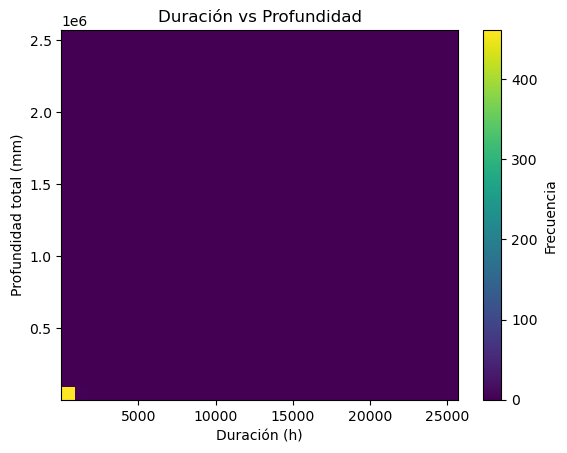

In [45]:
plt.figure()
plt.hist2d(
    eventos_df["duracion_horas"],
    eventos_df["profundidad_total_mm"],
    bins=30
)
plt.xlabel("Duración (h)")
plt.ylabel("Profundidad total (mm)")
plt.colorbar(label="Frecuencia")
plt.title("Duración vs Profundidad")
plt.show()

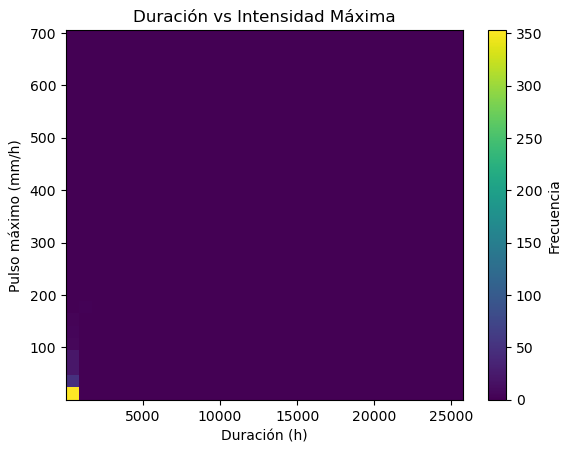

In [46]:
plt.figure()
plt.hist2d(
    eventos_df["duracion_horas"],
    eventos_df["pulso_maximo_mm"],
    bins=30
)
plt.xlabel("Duración (h)")
plt.ylabel("Pulso máximo (mm/h)")
plt.colorbar(label="Frecuencia")
plt.title("Duración vs Intensidad Máxima")
plt.show()

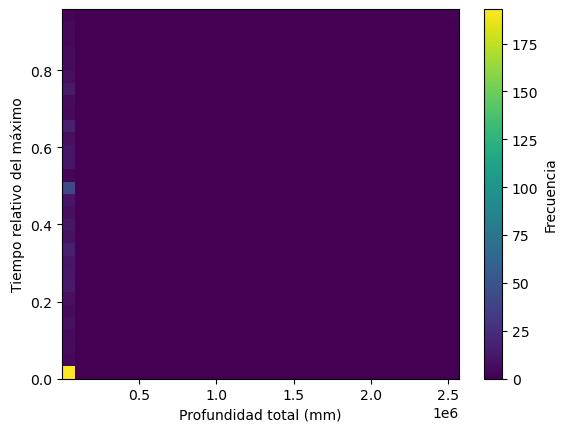

In [47]:
plt.figure()
plt.hist2d(
    eventos_df["profundidad_total_mm"],
    eventos_df["tiempo_max_relativo"],
    bins=30
)
plt.xlabel("Profundidad total (mm)")
plt.ylabel("Tiempo relativo del máximo")
plt.colorbar(label="Frecuencia")
plt.show()

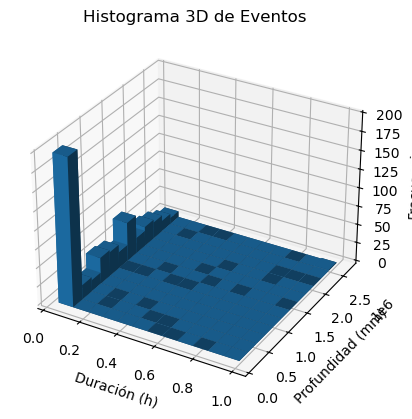

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

x = eventos_df["tiempo_max_relativo"]
y = eventos_df["profundidad_total_mm"]

hist, xedges, yedges = np.histogram2d(x, y, bins=12)

xpos, ypos = np.meshgrid(
    xedges[:-1] + np.diff(xedges)/2,
    yedges[:-1] + np.diff(yedges)/2
)

xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros_like(xpos)

dx = np.diff(xedges)[0]
dy = np.diff(yedges)[0]
dz = hist.flatten()

ax.bar3d(xpos, ypos, zpos, dx, dy, dz)

ax.set_xlabel("Duración (h)")
ax.set_ylabel("Profundidad (mm)")
ax.set_zlabel("Frecuencia")

plt.title("Histograma 3D de Eventos")
plt.show()

In [ ]:
cov_matrix = df[["BOD","NO3_N","NH3_N"]].cov()
print(cov_matrix)

In [ ]:
corr_matrix = df[["BOD","NO3_N","NH3_N"]].corr()
print(corr_matrix)

In [50]:
data = {
    "Station": list(range(1,39)),
    "BOD": [2.27,4.41,4.03,3.75,3.37,3.23,3.18,4.08,4,3.92,3.83,3.74,3.66,3.58,3.16,3.43,3.36,3.3,3.24,3.19,3.22,3.17,3.13,3.08,3.04,3,2.96,2.93,2.89,2.86,2.82,2.79,2.76,2.73,2.7,2.51,2.49,2.46],
    "NO3_N": [1.97,12.83,11.11,9.86,9.54,8.85,8.02,8.94,8.76,8.59,8.43,8.27,8.13,7.99,6.72,9.23,9.1,8.97,8.85,8.74,9.8,9.64,9.49,9.34,9.2,9.06,8.03,8.81,8.69,8.57,8.45,8.35,8.24,8.14,8.04,6.54,6.51,6.46],
    "NH3_N": [0.11,0.61,0.53,0.47,0.62,0.56,0.64,1.14,1.11,1.07,1.04,1,0.97,0.94,0.83,0.94,0.93,0.91,0.89,0.88,0.95,0.93,0.9,0.88,0.86,0.84,0.82,0.8,0.78,0.76,0.74,0.73,0.71,0.7,0.68,0.48,0.47,0.46]
}

df = pd.DataFrame(data)

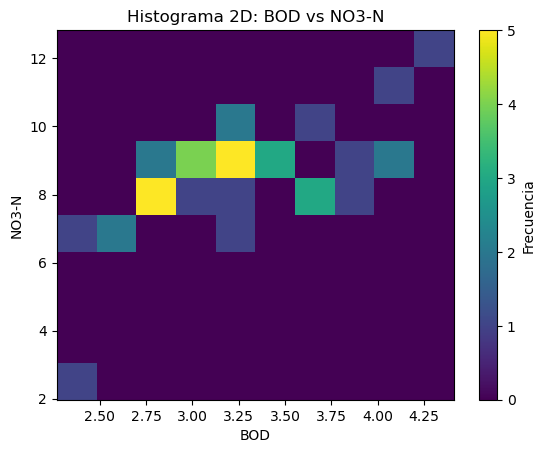

In [51]:
plt.figure()
plt.hist2d(df["BOD"], df["NO3_N"], bins=10)
plt.xlabel("BOD")
plt.ylabel("NO3-N")
plt.colorbar(label="Frecuencia")
plt.title("Histograma 2D: BOD vs NO3-N")
plt.show()

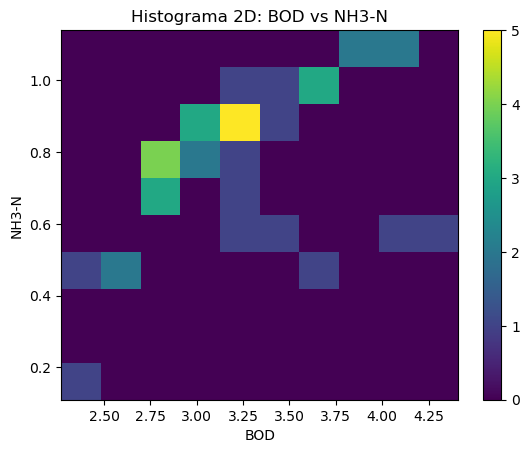

In [52]:
plt.figure()
plt.hist2d(df["BOD"], df["NH3_N"], bins=10)
plt.xlabel("BOD")
plt.ylabel("NH3-N")
plt.colorbar()
plt.title("Histograma 2D: BOD vs NH3-N")
plt.show()

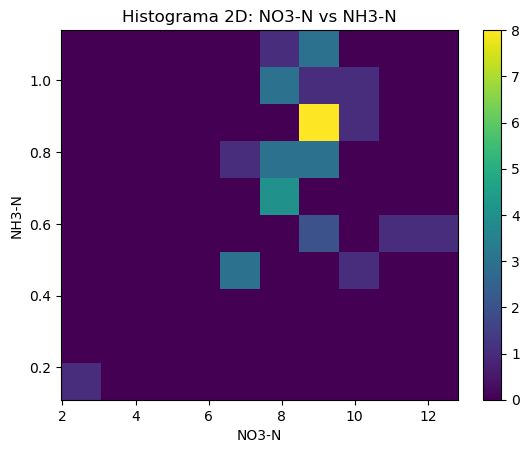

In [53]:
plt.figure()
plt.hist2d(df["NO3_N"], df["NH3_N"], bins=10)
plt.xlabel("NO3-N")
plt.ylabel("NH3-N")
plt.colorbar()
plt.title("Histograma 2D: NO3-N vs NH3-N")
plt.show()

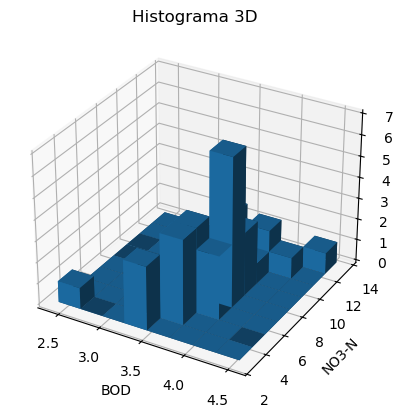

In [54]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

x = df["BOD"]
y = df["NO3_N"]

hist, xedges, yedges = np.histogram2d(x, y, bins=8)

xpos, ypos = np.meshgrid(
    xedges[:-1] + np.diff(xedges)/2,
    yedges[:-1] + np.diff(yedges)/2
)

xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros_like(xpos)

dx = np.diff(xedges)[0]
dy = np.diff(yedges)[0]
dz = hist.flatten()

ax.bar3d(xpos, ypos, zpos, dx, dy, dz)

ax.set_xlabel("BOD")
ax.set_ylabel("NO3-N")
ax.set_zlabel("Frecuencia")

plt.title("Histograma 3D")
plt.show()

In [55]:
cov_matrix = df[["BOD","NO3_N","NH3_N"]].cov()
print(cov_matrix)

            BOD     NO3_N     NH3_N
BOD    0.252462  0.522586  0.055859
NO3_N  0.522586  2.563909  0.143486
NH3_N  0.055859  0.143486  0.046539


In [56]:
corr_matrix = df[["BOD","NO3_N","NH3_N"]].corr()
print(corr_matrix)

            BOD     NO3_N     NH3_N
BOD    1.000000  0.649544  0.515332
NO3_N  0.649544  1.000000  0.415382
NH3_N  0.515332  0.415382  1.000000


# PUNTO 3

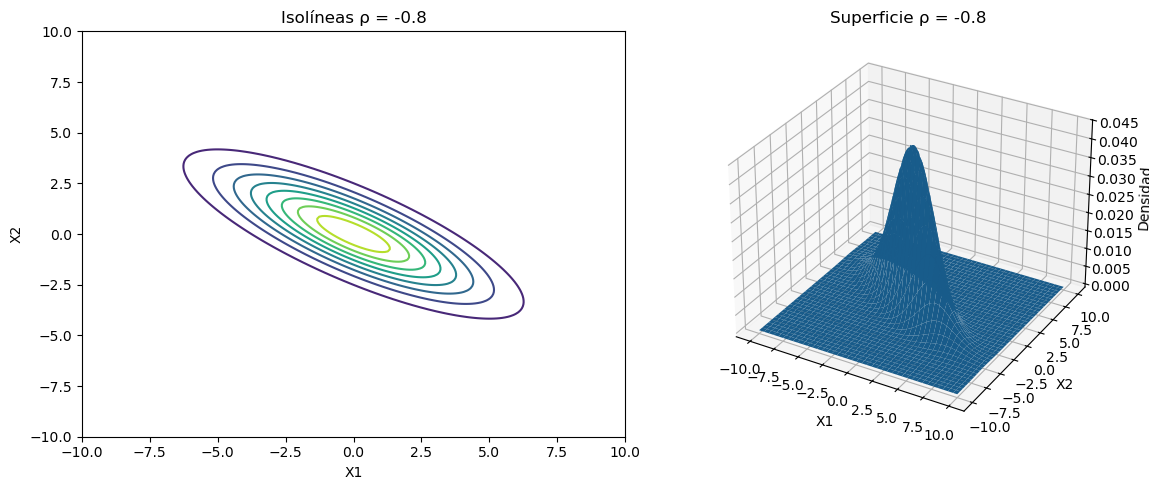

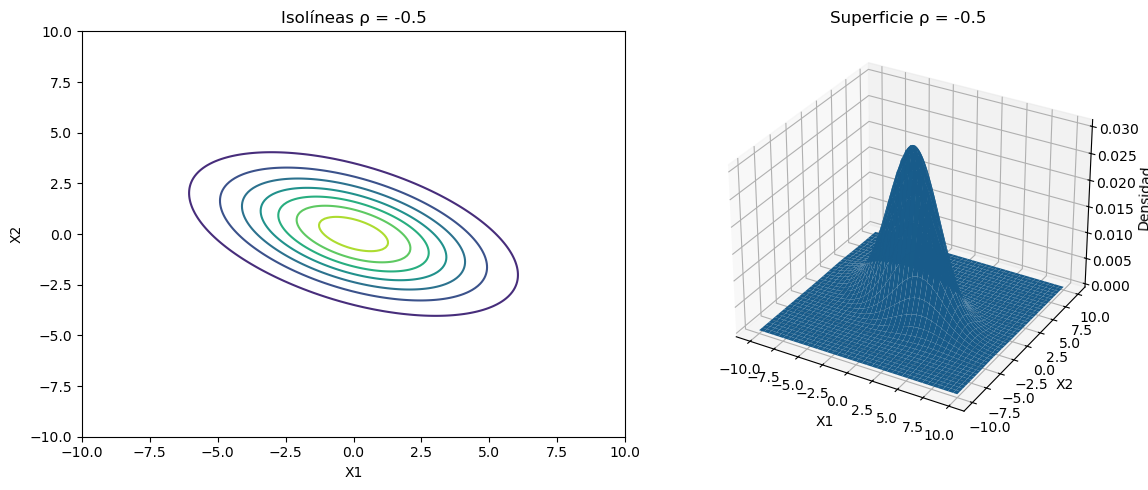

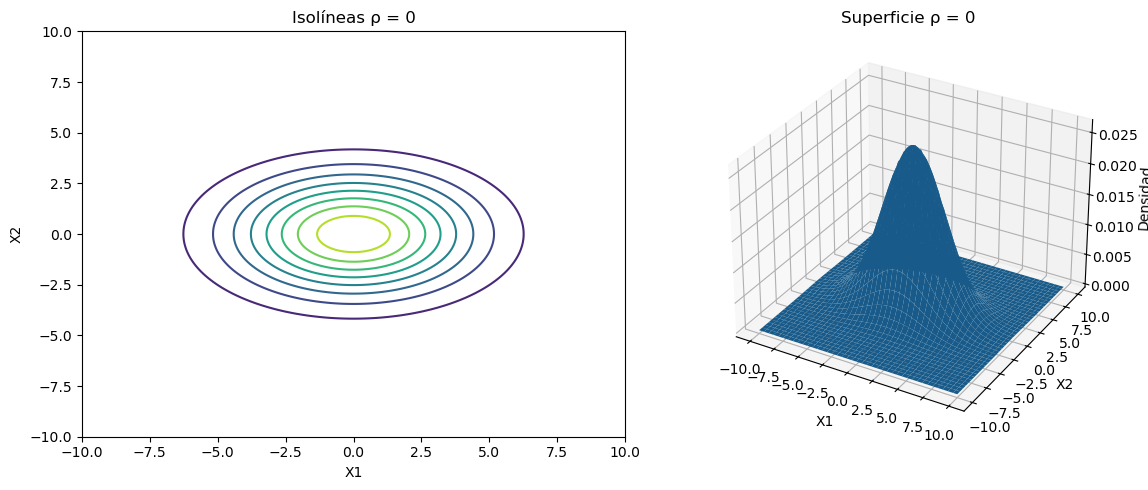

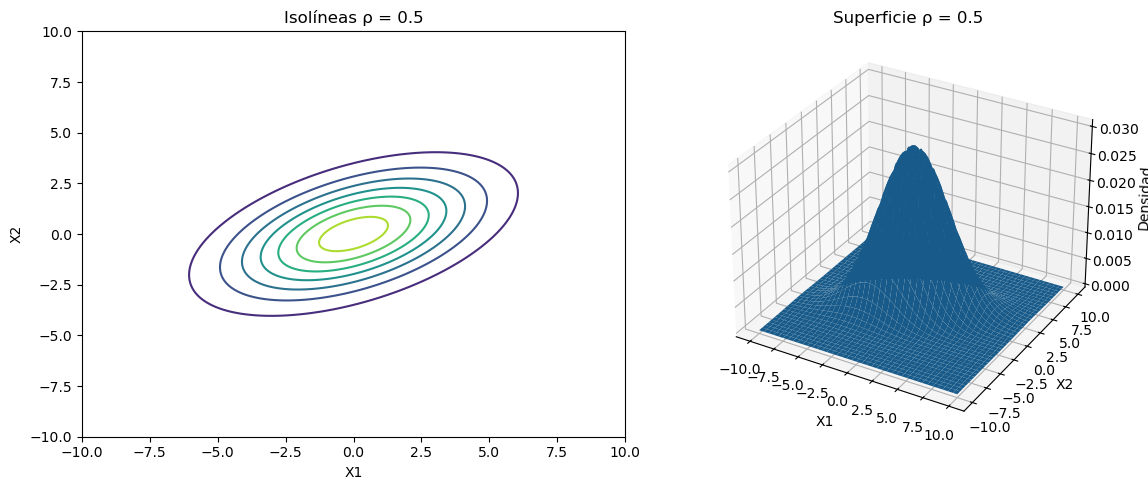

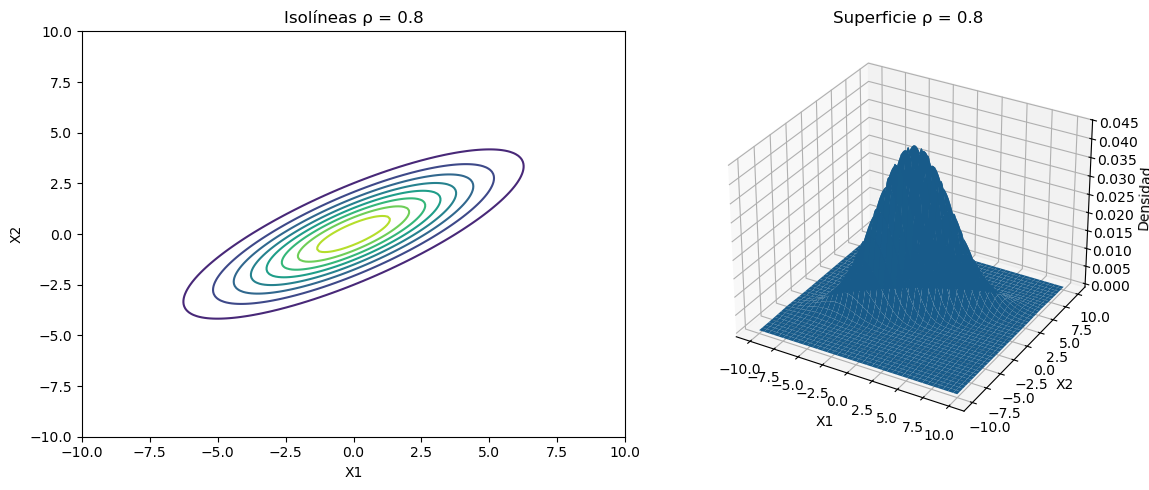

In [58]:
sigma1 = 3
sigma2 = 2

rhos = [-0.8, -0.5, 0, 0.5, 0.8]

x = np.linspace(-10,10,200)
y = np.linspace(-10,10,200)
X, Y = np.meshgrid(x,y)
pos = np.dstack((X,Y))

for rho in rhos:
    
    cov12 = rho * sigma1 * sigma2
    Sigma = np.array([[9, cov12],
                      [cov12, 4]])
    
    rv = multivariate_normal(mean=[0,0], cov=Sigma)
    Z = rv.pdf(pos)
    
    fig = plt.figure(figsize=(12,5))
    
    # --- Isolíneas ---
    ax1 = fig.add_subplot(1,2,1)
    cs = ax1.contour(X,Y,Z, levels=8)
    ax1.set_title(f"Isolíneas ρ = {rho}")
    ax1.set_xlabel("X1")
    ax1.set_ylabel("X2")
    
    # --- Superficie 3D ---
    ax2 = fig.add_subplot(1,2,2, projection='3d')
    ax2.plot_surface(X,Y,Z, rstride=5, cstride=5)
    ax2.set_title(f"Superficie ρ = {rho}")
    ax2.set_xlabel("X1")
    ax2.set_ylabel("X2")
    ax2.set_zlabel("Densidad")
    
    plt.tight_layout()
    plt.show()

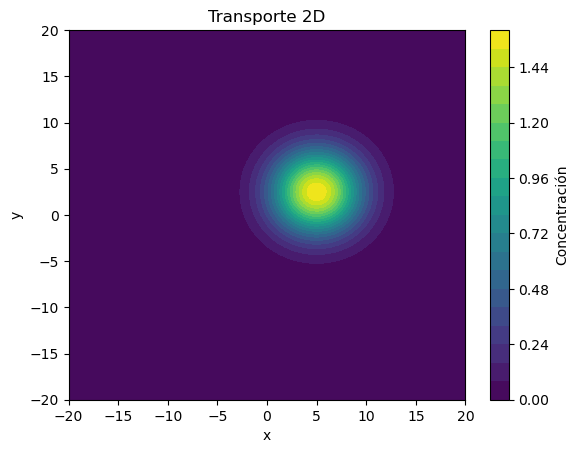

In [59]:
M = 100
Dx = 1
Dy = 1
u = 1
v = 0.5
t = 5

x = np.linspace(-20,20,200)
y = np.linspace(-20,20,200)
X,Y = np.meshgrid(x,y)

C = (M/(4*np.pi*t*np.sqrt(Dx*Dy))) * np.exp(
    -((X-u*t)**2)/(4*Dx*t)
    -((Y-v*t)**2)/(4*Dy*t)
)

plt.figure()
plt.contourf(X,Y,C, levels=20)
plt.colorbar(label="Concentración")
plt.title("Transporte 2D")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

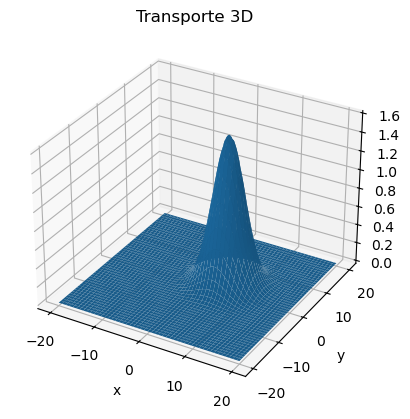

In [60]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X,Y,C)
ax.set_title("Transporte 3D")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("C")
plt.show()

# PUNTO 4

In [2]:
# Definición de la función Goldstein-Price
def goldstein_price(x1, x2):
    term1 = 1 + (x1 + x2 + 1)**2 * (
        19 - 14*x1 + 3*x1**2 - 14*x2 + 6*x1*x2 + 3*x2**2
    )
    
    term2 = 30 + (2*x1 - 3*x2)**2 * (
        18 - 32*x1 + 12*x1**2 + 48*x2 - 36*x1*x2 + 27*x2**2
    )
    
    return term1 * term2

In [12]:
print("Valor en (0,-1):", goldstein_price(0, -1))

Valor en (0,-1): 3


In [11]:
import sympy as sp

x1, x2 = sp.symbols('x1 x2')

f = (1 + (x1 + x2 + 1)**2 *
     (19 - 14*x1 + 3*x1**2 - 14*x2 + 6*x1*x2 + 3*x2**2)) * \
    (30 + (2*x1 - 3*x2)**2 *
     (18 - 32*x1 + 12*x1**2 + 48*x2 - 36*x1*x2 + 27*x2**2))

df_dx1 = sp.diff(f, x1)
df_dx2 = sp.diff(f, x2)

print(df_dx1.subs({x1:0, x2:-1}))
print(df_dx2.subs({x1:0, x2:-1}))

0
0


In [3]:
# Dominio
x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)

X, Y = np.meshgrid(x, y)
Z = goldstein_price(X, Y)

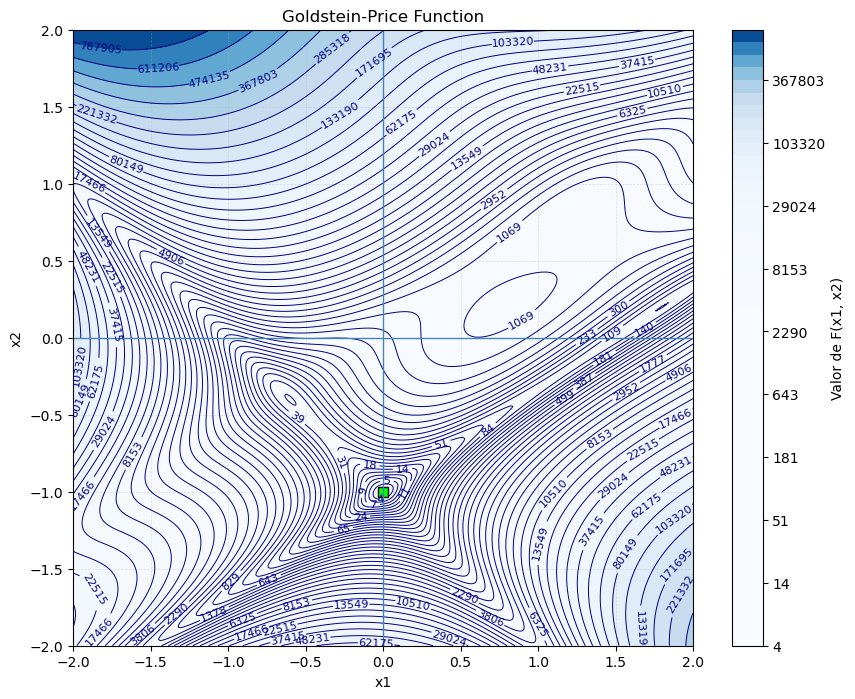

In [8]:
# Figura
fig, ax = plt.subplots(figsize=(10,8))

# Fondo gris claro
ax.set_facecolor('#f2f2f2')

# Niveles logarítmicos (mejor distribución visual)
levels = np.logspace(np.log10(Z.min()+1), np.log10(Z.max()), 50)

# Contorno coloreado
contour_filled = ax.contourf(X, Y, Z, levels=levels, cmap='Blues')

# Líneas de isolíneas
contours = ax.contour(X, Y, Z, levels=levels, colors='navy', linewidths=0.7)

# Etiquetas sobre las curvas
ax.clabel(contours, inline=True, fontsize=8, fmt="%.0f")

# Colorbar
cbar = fig.colorbar(contour_filled)
cbar.set_label("Valor de F(x1, x2)")

# Mínimo global
ax.plot(0, -1, marker='s', markersize=7, markerfacecolor='lime', markeredgecolor='black')

# Ejes cruzados en cero
ax.axhline(0, color='steelblue', linewidth=1)
ax.axvline(0, color='steelblue', linewidth=1)

# Grid suave
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

# Etiquetas
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Goldstein-Price Function")

plt.show()